In [0]:
%run ./utils

About Gold_stats notebook: It gives idea about has there been a statistically significant and meaningful shift in revenue and product behaviour between the current(2023) and previous(2022) sales periods?


To answer this question we calculate:

-Discriptive statistics(mean,std,skewness,kurtosis)

-Data precision & consistency analysis

-Visual EDA (histograms, box plots, scatter plots, correlation heatmaps)

-Correlation drift detection (Pearson)

-Hypothesis testing (Independent Samples T-Test)

-One-Way ANOVA across product categories

These tables represent two distinct sales periods and have already been cleaned and validated in the Silver layer. All further analysis will compare these two datasets.

In [0]:
from pyspark.sql.functions import *
from scipy import stats

try:
    write_log("GOLD_START", "STARTED", "Gold statistical audit started")
# Load the data
    df_curr=spark.read.table("amazon_project.silver.current_clean")
    df_prev=spark.read.table("amazon_project.silver.previous_clean")

    write_log("GOLD_READ", "INFO", "Loaded Silver tables")

# Comparing data
    def get_stats(df, label):
        return df.select(
            lit(label).alias("dataset"),
            mean("total_revenue").alias("avg_revenue"),
            stddev("total_revenue").alias("std_dev"),
            skewness("total_revenue").alias("skewness"),
            kurtosis("total_revenue").alias("kurtosis")
        )

    dna_curr=get_stats(df_curr, "Current")
    dna_prev=get_stats(df_prev, "Previous")

    dna_report=dna_curr.union(dna_prev)

    write_log("GOLD_STATS", "INFO", "Statistical distribution calculated")

  
# HYPOTHESIS TEST (T-TEST)

    # Convert to Pandas
    curr_pdf=df_curr.select("total_revenue").dropna().toPandas()["total_revenue"].astype(float)
    prev_pdf=df_prev.select("total_revenue").dropna().toPandas()["total_revenue"].astype(float)

    t_stat, p_value=stats.ttest_ind(curr_pdf, prev_pdf)

    write_log("GOLD_TTEST", "INFO", f"T-test completed. P-value: {p_value:.4f}")


# FINAL OUTPUT

    final_report=dna_report \
        .withColumn("p_value", lit(float(p_value))) \
        .withColumn("is_drifted", (col("p_value") < 0.05))

# Save Table to gold
    final_report.write.mode("overwrite").saveAsTable(
        "amazon_project.gold.statistics_compare"
    )

    write_log("GOLD_END", "SUCCESS", f"Audit complete. P-value: {p_value:.4f}")

except Exception as e:
    write_log("GOLD_ERROR", "FAILED", str(e))
    raise   

H0: there is no difference between 2022 and 2023 revenue

H1: Revenue has changed

The difference between curr and pre revenue is not random. It is real change

In [0]:
display(final_report)

dataset,avg_revenue,std_dev,skewness,kurtosis,p_value,is_drifted
Current,765.8034908670312,660.5421191513732,1.4192891503740086,3.0593611005272177,9.768652342559257E-91,true
Previous,657.5224488485911,527.8531638178317,0.9801234242322938,0.27185871170371056,9.768652342559257E-91,true


check precision 


**Precision** is computed as the inverse of standard deviation(1/sigma).
Higher precision means the data is tightly clustered (more consistent / stable).And a lower precision means the data is widely spread (more volatile / fluctuating).

In [0]:
import numpy as np

# Current dataset
std_curr=np.std(curr_pdf)
precision_curr=1 / std_curr

# Previous dataset
std_prev=np.std(prev_pdf)
precision_prev= 1 / std_prev

print("Current Precision:", precision_curr)
print("Previous Precision:", precision_prev)

Current Precision: 0.0015139381919444667
Previous Precision: 0.0018945042457384213


current prcision is less than previous presion so current data is less consistent that the prev.Prev data is more stable.Curr data is showing fluctuations

### EDA

Revenue Distribution (Histogram + KDE + Normal Curve)

This plot overlays the empirical distribution (histogram + KDE) with a fitted normal curve.Divergence between the two reveals skewness or heavy tails in the data.Vertical mean lines make it easy to spot shifts in central tendency between periods.




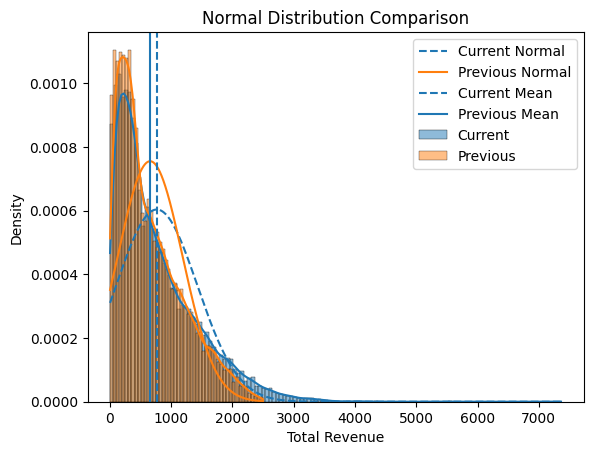

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Convert data
curr_pdf=df_curr.select("total_revenue").dropna().toPandas()['total_revenue']
prev_pdf=df_prev.select("total_revenue").dropna().toPandas()['total_revenue']

# Compute stats separately
mean_curr=np.mean(curr_pdf)
std_curr=np.std(curr_pdf)

mean_prev=np.mean(prev_pdf)
std_prev=np.std(prev_pdf)

# Create x ranges
x_curr=np.linspace(curr_pdf.min(), curr_pdf.max(), 1000)
x_prev=np.linspace(prev_pdf.min(), prev_pdf.max(), 1000)

plt.figure()

# Histograms with labels 
sns.histplot(curr_pdf, kde=True, label="Current", stat="density")
sns.histplot(prev_pdf, kde=True, label="Previous", stat="density")

# Normal curves with different styles 
plt.plot(x_curr, stats.norm.pdf(x_curr, mean_curr, std_curr), linestyle='--', label="Current Normal")
plt.plot(x_prev, stats.norm.pdf(x_prev, mean_prev, std_prev), linestyle='-', label="Previous Normal")

# Mean lines 
plt.axvline(mean_curr, linestyle='--', label="Current Mean")
plt.axvline(mean_prev, linestyle='-', label="Previous Mean")

plt.title("Normal Distribution Comparison")
plt.xlabel("Total Revenue")
plt.ylabel("Density")
plt.legend()

plt.show()

Box plot (Price Distribution)
Box plots reveal the median, interquartile range (IQR), and outliers for `price`across both periods. Any upward or downward shift in median pricing, or widening of the IQR, is immediately visible.

/root/.ipykernel/2655/command-6455842630273296-4143014052:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


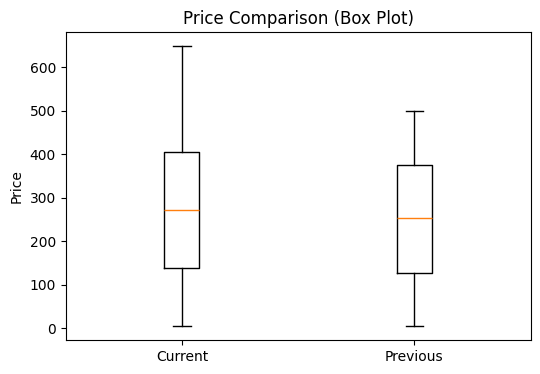

In [0]:
df_curr=spark.table("amazon_project.silver.current_clean").toPandas()
df_prev=spark.table("amazon_project.silver.previous_clean").toPandas()

plt.figure(figsize=(6, 4))

plt.boxplot(
    [df_curr["price"], df_prev["price"]],
    labels=["Current", "Previous"]
)

plt.title("Price Comparison (Box Plot)")
plt.ylabel("Price")

plt.show()

Price vs Quantity Sold (Scatter Plot)

This scatter plot explores whether a price–demand relationship exists(i.e., do higher prices correlate with lower quantities sold?).Comparing the two periods side-by-side reveals whether this relationship has strengthened, weakened, or shifted.

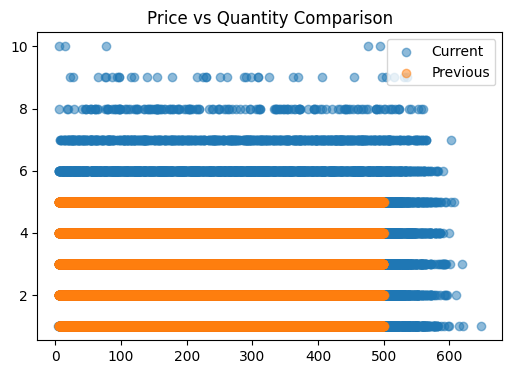

In [0]:
df_prev=spark.table("amazon_project.silver.previous_clean").toPandas()
df_curr=spark.table("amazon_project.silver.current_clean").toPandas()
plt.figure(figsize=(6, 4))

plt.scatter(df_curr["price"], df_curr["quantity_sold"], alpha=0.5, label="Current")
plt.scatter(df_prev["price"], df_prev["quantity_sold"], alpha=0.5, label="Previous")

plt.legend()
plt.title("Price vs Quantity Comparison")

plt.show()

Average Revenue by Product Category (Bar Chart) 

This chart shows whether certain product categories are growing or declining in average revenue between the two periods. Category-level shifts are often the root cause of aggregate revenue drift.

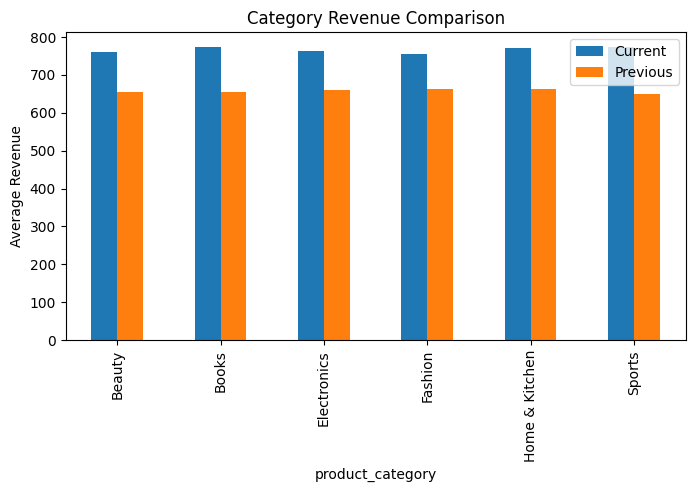

In [0]:
import pandas as pd
df_curr=spark.table("amazon_project.silver.current_clean").toPandas()
df_prev=spark.table("amazon_project.silver.previous_clean").toPandas()

curr_cat=df_curr.groupby("product_category")["total_revenue"].mean()
prev_cat=df_prev.groupby("product_category")["total_revenue"].mean()

combined=pd.DataFrame({
    "Current": curr_cat,
    "Previous": prev_cat
})

combined.plot(kind="bar", figsize=(8, 4))

plt.title("Category Revenue Comparison")
plt.ylabel("Average Revenue")

plt.show()

Correlation Heatmap

Compute Pearson correlation matrices for `price`, `quantity_sold`, `rating`,and `total_revenue` in both periods. Strong correlations indicate linear relationships between features.

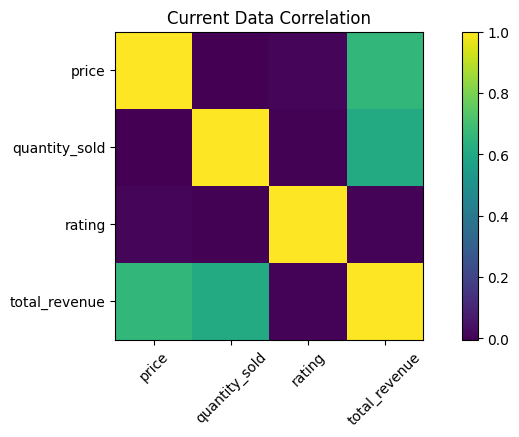

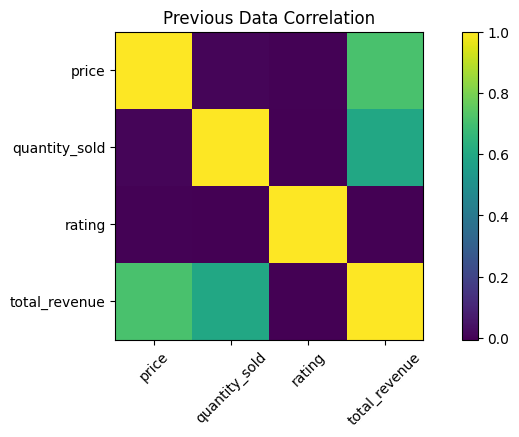

In [0]:
import matplotlib.pyplot as plt

# Convert Spark → Pandas
df_curr=spark.table("amazon_project.silver.current_clean").toPandas()
df_prev=spark.table("amazon_project.silver.previous_clean").toPandas()

# Select columns
cols=["price", "quantity_sold", "rating", "total_revenue"]

# Correlation
corr_curr=df_curr[cols].corr()
corr_prev=df_prev[cols].corr()

# Plot Current
plt.figure(figsize=(10,4))
plt.imshow(corr_curr)
plt.title("Current Data Correlation")
plt.colorbar()
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.show()

# Plot Previous
plt.figure(figsize=(10,4))
plt.imshow(corr_prev)
plt.title("Previous Data Correlation")
plt.colorbar()
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.show()

### Correlation drift

It is calculated as the difference between the two matrices (`corr_current - corr_previous`). A drift value close to zero means the relationship is stable. A large drift indicates that feature interactions have meaningfully changed-an important signal for model retraining in ML pipelines.


In [0]:

try:
# Column selection
    df_curr=spark.table("amazon_project.silver.current_clean").toPandas()
    df_prev=spark.table("amazon_project.silver.previous_clean").toPandas()
    num_cols=["price", "quantity_sold", "rating", "total_revenue"]
# Create correlation matrix
    corr_curr=df_curr[num_cols].corr()
    corr_prev=df_prev[num_cols].corr()
# Calcutlate correlation drift
   
    corr_drift=corr_curr - corr_prev

    drift_df=corr_drift.stack().reset_index()
    drift_df.columns=["feature_1", "feature_2", "correlation_change"]

    spark.createDataFrame(drift_df).write.mode("overwrite") \
        .saveAsTable("amazon_project.gold.correlation_drift")

except Exception as e:
    write_log("GOLD_STATS_ERROR", "FAILED", str(e))
    raise

In [0]:
%sql
select * from amazon_project.gold.correlation_drift

feature_1,feature_2,correlation_change
price,price,0.0
price,quantity_sold,-0.01148579471858883
price,rating,0.006888159288551554
price,total_revenue,-0.04879691866651281
quantity_sold,price,-0.01148579471858883
quantity_sold,quantity_sold,0.0
quantity_sold,rating,0.005647368616980299
quantity_sold,total_revenue,0.011006662570685277
rating,price,0.006888159288551554
rating,quantity_sold,0.005647368616980299


Based on karl pearsons correlation drift


### Hypothesis Testing


**Question:** Is the difference in mean revenue between the current and previous periods statistically significant, or could it be due to random chance?

**Method:** We use Welch's independent samples T-test (`scipy.stats.ttest_ind`),
which compares the means of two independent samples without assuming equal variances.

**Decision rule:**
**p-value < 0.05** → Reject the null hypothesis. The revenue shift is **statistically significant** — it reflects a real business change, not noise.

**p-value ≥ 0.05** → Fail to reject. The difference could be due to random variation.
**Note on large datasets:** With very large sample sizes, even trivially small differences can produce p < 0.05. Always interpret the p-value alongside the practical magnitude of the difference (effect size / business impact).


In [0]:
from scipy import stats

try:
    df_curr=spark.read.table("amazon_project.silver.current_clean")
    df_prev=spark.read.table("amazon_project.silver.previous_clean")
    curr_revenue=df_curr.select("total_revenue").toPandas()["total_revenue"]
    prev_revenue=df_prev.select("total_revenue").toPandas()["total_revenue"]
    t_stat, p_value=stats.ttest_ind(curr_revenue, prev_revenue)

    if p_value < 0.05:
        result="Significant Change"
    else:
        result="No Significant Change"

    print(f"T-Statistic: {t_stat}")
    print(f"P-Value: {p_value}")
    print(f"Result: {result}")


    result_df=spark.createDataFrame([
        ("T-Test Revenue Comparison", float(p_value), result)
    ], ["test_name", "p_value", "result"])

    result_df.write.mode("overwrite") \
        .saveAsTable("amazon_project.gold.ttest_results")


except Exception as e:
    write_log("TTEST_ERROR", "FAILED", str(e))
    raise

T-Statistic: 20.241492483816184
P-Value: 9.768652342559257e-91
Result: Significant Change


If P-value is less than 0.05, we can confidently say that the revenue change is not random and indicates a real business shift.

No need to check any test because p value is significantly small for the large dataset so it is showing large drift in the data 

One-Way ANOVA - Revenue Across Product Categories

**Question:** Within each period, is `total_revenue` significantly different across product categories? Or do all categories perform similarly?

**Method:** One-Way ANOVA (`scipy.stats.f_oneway`) tests whether the means of
three or more independent groups differ significantly.

**Decision rule:** p-value < 0.05 means At least one category has significantly different revenue from the others.
p-value ≥ 0.05 means No significant difference; all categories behave similarly within this period.
This complements the T-test by telling us whether the observed drift is uniform across categories or driven by specific segments.

In [0]:
from scipy.stats import f_oneway
import pandas as pd

try:
    write_log("ANOVA_START", "STARTED", "ANOVA analysis started")
    df_curr=spark.table("amazon_project.silver.current_clean").toPandas()
    df_prev=spark.table("amazon_project.silver.previous_clean").toPandas()
    # get unique categories
    categories_curr=df_curr["product_category"].unique()
    categories_prev=df_prev["product_category"].unique()

    curr_groups=[
        df_curr[df_curr["product_category"] == cat]["total_revenue"]
        for cat in categories_curr
    ]
# ANOVA for current dataset
    f_curr, p_curr=f_oneway(*curr_groups)
# prev group
    prev_groups=[
        df_prev[df_prev["product_category"] == cat]["total_revenue"]
        for cat in categories_prev
    ]
# ANOVA for Previous dataset
  
    f_prev, p_prev=f_oneway(*prev_groups)

# result table
    result=pd.DataFrame({
        "dataset": ["current", "previous"],
        "f_statistic": [f_curr, f_prev],
        "p_value": [p_curr, p_prev],
        "result": [
            "Significant" if p_curr < 0.05 else "Not Significant",
            "Significant" if p_prev < 0.05 else "Not Significant"
        ]
    })

    spark_df=spark.createDataFrame(result)

    spark_df.write.mode("overwrite").saveAsTable("amazon_project.gold.anova_results")

    write_log("ANOVA_END", "SUCCESS", "ANOVA completed successfully")

except Exception as e:
    write_log("ANOVA_ERROR", "FAILED", str(e))
    raise

Comparing: Categories within SAME dataset-
All categories behave similarly (no strong difference is visible)

In [0]:
display(spark_df,truncate=False)

dataset,f_statistic,p_value,result
current,0.5724238321804177,0.7212316519321669,Not Significant
previous,0.47639307454243623,0.7941523818180128,Not Significant


In [0]:
%sql
SELECT *
FROM amazon_project.metadeta.pipeline_logs
ORDER BY timestamp DESC

id,step,status,message,timestamp
76ae25e6-3037-422e-a1a7-fe116f3d7920,ANOVA_END,SUCCESS,ANOVA completed successfully,2026-04-07T04:48:57.741222Z
451cc4ef-1f9e-40ed-94a7-9fb1d8e4cdd3,ANOVA_START,STARTED,ANOVA analysis started,2026-04-07T04:48:53.927678Z
626a57e1-1ef5-445e-8a81-ad831297ed26,GOLD_END,SUCCESS,Audit complete. P-value: 0.0000,2026-04-07T04:46:42.171768Z
ce49ec8b-a54b-441b-8672-803c506229f5,GOLD_TTEST,INFO,T-test completed. P-value: 0.0000,2026-04-07T04:46:32.94974Z
33676489-16c7-41c5-9a8f-667e58789301,GOLD_STATS,INFO,Statistical distribution calculated,2026-04-07T04:46:29.626017Z
4dde1121-b559-4667-b0d8-969dc0ef0165,GOLD_READ,INFO,Loaded Silver tables,2026-04-07T04:46:28.419994Z
b677f65b-0bbf-464e-b45e-c2bc57925eb1,GOLD_START,STARTED,Gold statistical audit started,2026-04-07T04:46:26.476441Z
ac106041-fe77-4bdc-bb1c-323b72ebc775,SILVER_END,SUCCESS,Data cleaned and saved to Silver tables,2026-04-07T04:44:18.703238Z
8a43a9da-55db-48cd-9e30-28b9f5f3155b,SILVER_TRANSFORM,INFO,Cleaning + casting applied,2026-04-07T04:44:06.712387Z
a94a1f73-03c5-4ee5-8b57-fd1c627aa6d0,SILVER_READ,INFO,Read data from Bronze tables,2026-04-07T04:44:04.655749Z
